# Exercise: Neural Networks

## 1. Import the required libraries in the cell below

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

## 2. Read the data

In [2]:
housing = pd.read_csv('data/sacramento_real_estate_transactions.csv')


## 3. Conduct Exploratory Data Analysis 

In [3]:
# Check data info
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 156.9 KB


In [4]:
# Check for missing values
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [5]:
# Check data types
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [6]:
# Look at the Summary Stats.
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [7]:
# Cleaning Steps (if needed)


In [8]:
housing.value_counts(housing['state'])

state
CA    984
AC      1
Name: count, dtype: int64

In [9]:
#Check All cities in CA state? Yes
housing.value_counts(housing['city'])

city
SACRAMENTO         439
ELK GROVE          114
LINCOLN             72
ROSEVILLE           48
CITRUS HEIGHTS      35
ANTELOPE            33
RANCHO CORDOVA      28
EL DORADO HILLS     23
NORTH HIGHLANDS     21
GALT                21
CARMICHAEL          20
FOLSOM              17
ROCKLIN             17
RIO LINDA           13
ORANGEVALE          11
PLACERVILLE         10
FAIR OAKS            9
CAMERON PARK         9
WILTON               5
AUBURN               5
ELVERTA              4
GOLD RIVER           4
POLLOCK PINES        3
RANCHO MURIETA       3
GRANITE BAY          3
WEST SACRAMENTO      3
LOOMIS               2
EL DORADO            2
MATHER               1
GREENWOOD            1
MEADOW VISTA         1
PENRYN               1
FORESTHILL           1
DIAMOND SPRINGS      1
SHINGLE SPRINGS      1
COOL                 1
WALNUT GROVE         1
GARDEN VALLEY        1
SLOUGHHOUSE          1
Name: count, dtype: int64

In [10]:
housing.nlargest(10, 'sq__ft')

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
866,14151 INDIO DR,SLOUGHHOUSE,95683,CA,3,4,5822,Residential,Fri May 16 00:00:00 EDT 2008,2000,38.490447,-121.129337
864,9401 BARREL RACER CT,WILTON,95693,CA,4,3,4400,Residential,Fri May 16 00:00:00 EDT 2008,884790,38.415298,-121.194858
534,5201 BLOSSOM RANCH DR,ELK GROVE,95757,CA,4,4,4303,Residential,Mon May 19 00:00:00 EDT 2008,450000,38.399436,-121.444041
535,3027 PALMATE WAY,SACRAMENTO,95834,CA,5,3,4246,Residential,Mon May 19 00:00:00 EDT 2008,452000,38.628955,-121.529269
317,9760 LAZULITE CT,ELK GROVE,95624,CA,4,3,3992,Residential,Tue May 20 00:00:00 EDT 2008,460000,38.403609,-121.335541
328,7756 TIGERWOODS DR,SACRAMENTO,95829,CA,5,3,3984,Residential,Tue May 20 00:00:00 EDT 2008,572500,38.476430,-121.309243
319,5559 NORTHBOROUGH DR,SACRAMENTO,95835,CA,5,3,3881,Residential,Tue May 20 00:00:00 EDT 2008,471750,38.677225,-121.519687
855,9880 IZILDA CT,SACRAMENTO,95829,CA,5,4,3863,Residential,Fri May 16 00:00:00 EDT 2008,598695,38.453260,-121.325730
330,2981 WRINGER DR,ROSEVILLE,95661,CA,4,3,3838,Residential,Tue May 20 00:00:00 EDT 2008,613401,38.735373,-121.227072
552,12901 FURLONG DR,WILTON,95693,CA,5,3,3788,Residential,Mon May 19 00:00:00 EDT 2008,691659,38.413535,-121.188211


In [11]:
housing.nlargest(10, 'beds')

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
108,2912 NORCADE CIR,SACRAMENTO,95826,CA,8,4,3612,Multi-Family,Wed May 21 00:00:00 EDT 2008,282400,38.559505,-121.364839
157,315 JUMEL CT,EL DORADO HILLS,95762,CA,6,5,0,Residential,Wed May 21 00:00:00 EDT 2008,830000,38.669931,-121.059580
648,8198 STEVENSON AVE,SACRAMENTO,95828,CA,6,4,2475,Multi-Family,Fri May 16 00:00:00 EDT 2008,159900,38.465271,-121.404260
779,9452 RED SPRUCE WAY,ELK GROVE,95624,CA,6,3,2555,Residential,Fri May 16 00:00:00 EDT 2008,300000,38.404505,-121.346938
78,8373 BLACKMAN WAY,ELK GROVE,95624,CA,5,3,2136,Residential,Wed May 21 00:00:00 EDT 2008,223058,38.435436,-121.394536
91,8636 TEGEA WAY,ELK GROVE,95624,CA,5,3,2508,Residential,Wed May 21 00:00:00 EDT 2008,245918,38.443832,-121.382087
97,5529 LAGUNA PARK DR,ELK GROVE,95758,CA,5,3,2790,Residential,Wed May 21 00:00:00 EDT 2008,258000,38.425680,-121.438062
114,7731 MASTERS ST,ELK GROVE,95758,CA,5,3,2494,Residential,Wed May 21 00:00:00 EDT 2008,297000,38.442031,-121.410873
117,4727 SAVOIE WAY,SACRAMENTO,95835,CA,5,3,2800,Residential,Wed May 21 00:00:00 EDT 2008,304037,38.658182,-121.549521
119,9570 HARVEST ROSE WAY,SACRAMENTO,95827,CA,5,3,2367,Residential,Wed May 21 00:00:00 EDT 2008,315537,38.555993,-121.340352


In [12]:
housing['price_per_sqft'] = housing['price'] / housing['sq__ft']


In [13]:
housing.nsmallest(10, 'price_per_sqft')

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,price_per_sqft
866,14151 INDIO DR,SLOUGHHOUSE,95683,CA,3,4,5822,Residential,Fri May 16 00:00:00 EDT 2008,2000,38.490447,-121.129337,0.343525
603,8208 WOODYARD WAY,CITRUS HEIGHTS,95621,CA,3,2,1166,Residential,Fri May 16 00:00:00 EDT 2008,30000,38.715322,-121.314787,25.728988
867,7401 TOULON LN,SACRAMENTO,95828,CA,4,2,1512,Residential,Thu May 15 00:00:00 EDT 2008,56950,38.488628,-121.387759,37.665344
335,5840 WALERGA RD,SACRAMENTO,95842,CA,2,1,840,Condo,Mon May 19 00:00:00 EDT 2008,40000,38.673678,-121.357471,47.619048
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028,58.450728
366,7342 GIGI PL,SACRAMENTO,95828,CA,4,4,1995,Multi-Family,Mon May 19 00:00:00 EDT 2008,120000,38.490704,-121.410176,60.150376
609,3348 40TH ST,SACRAMENTO,95817,CA,2,1,1080,Residential,Fri May 16 00:00:00 EDT 2008,65000,38.544162,-121.460652,60.185185
172,3847 LAS PASAS WAY,SACRAMENTO,95864,CA,3,1,1643,Residential,Tue May 20 00:00:00 EDT 2008,99000,38.588672,-121.373916,60.255630
607,2332 CAMBRIDGE ST,SACRAMENTO,95815,CA,2,1,1032,Residential,Fri May 16 00:00:00 EDT 2008,65000,38.608085,-121.449651,62.984496
337,261 REDONDO AVE,SACRAMENTO,95815,CA,3,1,970,Residential,Mon May 19 00:00:00 EDT 2008,61500,38.620685,-121.460539,63.402062


In [14]:
#Range prices
housing=housing[
    (housing["sq__ft"] >= 100) &
    (housing["sq__ft"] <= 15000)
    ]
#Range 
housing=housing[
    (housing["price"] >= 0) &
    (housing["price"] <= 2500000)
    ]
# Transform zip code to integer number
housing['zip'] = housing['zip'].astype('Int64')

# Range CA latitude and longitude

housing=housing[
    (housing["beds"] >= 1) &
    (housing["baths"] >= 1)
    ]

housing = housing[
    (housing['latitude'] >= 32.5) &
    (housing['latitude'] <= 42.0) &
    (housing['longitude'] >= -124.5) &
    (housing['longitude'] <= -114.1)
]
housing['sale_date'] = housing['sale_date'].str.replace(' EDT', '', regex=False)
housing['sale_date'] = pd.to_datetime(housing['sale_date'])

In [15]:
housing

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,price_per_sqft
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879,70.839713
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028,58.450728
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839,86.532663
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146,81.346244
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768,102.760351
...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,Residential,2008-05-15,232425,38.457679,-121.359620,101.940789
981,6932 RUSKUT WAY,SACRAMENTO,95823,CA,3,2,1477,Residential,2008-05-15,234000,38.499893,-121.458890,158.429248
982,7933 DAFFODIL WAY,CITRUS HEIGHTS,95610,CA,3,2,1216,Residential,2008-05-15,235000,38.708824,-121.256803,193.256579
983,8304 RED FOX WAY,ELK GROVE,95758,CA,4,2,1685,Residential,2008-05-15,235301,38.417000,-121.397424,139.644510


In [16]:
#for more specific predict ignore most extreme values
low = housing['price'].quantile(0.05)
high = housing['price'].quantile(0.95)

housing = housing[housing['price'].between(low, high)]
housing.describe()

,zip,beds,baths,sq__ft,sale_date,price,latitude,longitude,price_per_sqft
count,731.0,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000
mean,95761.818057,3.262654,1.960328,1553.885089,2008-05-18 04:25:56.224350,219452.383037,38.575005,-121.382158,145.240285
min,95603.0,1.000000,1.000000,539.000000,2008-05-15 00:00:00,85000.000000,38.241514,-121.550527,60.150376
25%,95670.0,3.000000,2.000000,1161.000000,2008-05-16 00:00:00,155217.500000,38.472119,-121.452234,111.458980
50%,95820.0,3.000000,2.000000,1420.000000,2008-05-19 00:00:00,207973.000000,38.585291,-121.406824,137.559809
75%,95829.0,4.000000,2.000000,1800.000000,2008-05-20 00:00:00,274087.500000,38.675743,-121.328426,168.627436
max,95864.0,8.000000,4.000000,4303.000000,2008-05-21 00:00:00,452000.000000,39.008159,-120.597599,619.666048
std,85.377171,0.807135,0.610243,560.095846,NaN,84636.707809,0.127717,0.117572,47.456602


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [17]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

## 4. Split the Data & Pre-Processing
**Best Practice for Neural Network** Split your data before modeling into three part:

1. __The Training Set (The Textbook):__ This is the data the neural network actually looks at to learn. During the training loop, the network uses this data to adjust its **weights** and **biases** via backpropagation.

2. __The Validation Set (The Practice Quiz):__ This data evaluates the model *during* training to fine-tune settings. The model does not learn its weights from this data. Instead, the it uses the validation score to choose **hyperparameters** (like learning rate, number of layers, or node count) and to decide when to stop training (**early stopping**).


3. __The Test Set (The Final Exam):__ This data provides an unbiased, final evaluation of the model's real-world performance. This dataset is locked away until training is completely finished. It is only used *once* at the very end to see how well the network performs on truly unseen data.

__Typical Split Ratios__

Depending on the size of your total dataset, data scientists generally use these proportions:

| Dataset Size | Train | Validation | Test |
| :--- | :--- | :--- | :--- |
| **Traditional (Small/Medium Data)** | 60% | 20% | 20% |
| **Modern Deep Learning (Millions of Rows)** | 98% | 1% | 1% |

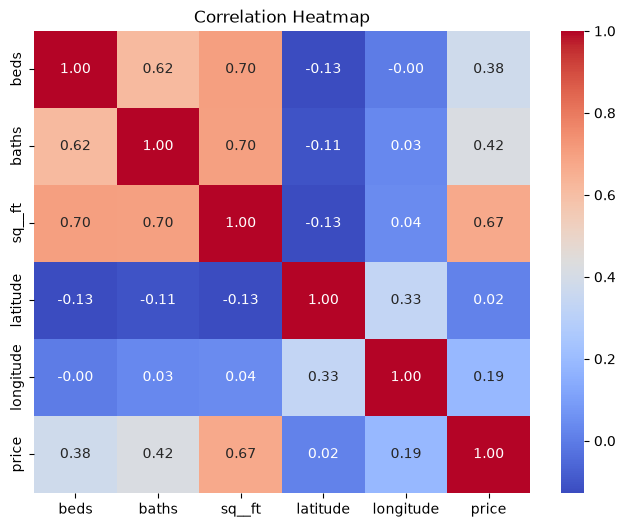

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select columns we want to investigate
cols = [
    'beds',
    'baths',
    'sq__ft',
    'latitude',
    'longitude',
    'price'
]

# Calculate correlation matrix
corr = housing[cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [19]:
# Select the Features and Target
features = [
    'beds',
    'baths',
    'sq__ft',
]

X = housing[features]
y = housing['price']

In [20]:
# Split to Train Test & Validation
X_train_all,X_test, y_train_all, y_test=train_test_split(X,y,test_size=.20,
                                                         random_state=42)
X_train, X_val, y_train,y_val = train_test_split(X_train_all,y_train_all,
                                                 test_size=.20,random_state=42)

In [21]:
# IMPORTANT: Scale the features for Neural Networks
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Learn mean/std ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 5. Linear Regression

In [22]:
# Initialize LinearRegression model
lr = LinearRegression()

In [23]:
# Fit and check the Training Score
lr.fit(X_train_scaled, y_train)

# Check training score (R²)
train_score = lr.score(X_train_scaled, y_train)

print("Training R²:", train_score)

Training R²: 0.5109788592613571


In [24]:
# Predict and check the Testing Score
y_pred = lr.predict(X_test_scaled)

# Check testing score (R²)
test_score = lr.score(X_test_scaled, y_test)

print("Testing R²:", test_score)

Testing R²: 0.3524341710532898


In [25]:
# Evaluate the model
# Coefficients
print("Coefficients:", lr.coef_)

# Intercept
print("Intercept:", lr.intercept_)

# RMSE
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

Coefficients: [-13095.81298116   -166.45422796  70739.18798673]
Intercept: 219578.27194860813
RMSE: 63389.74970017935


## 6. Build a Single Neural Network
Creating a model in `keras` entails a few steps:
1. Create your network topology
2. Compile your model
3. Fit your model
   
**Important Note on Regression:**
Because we are predicting a continuous value (house price), our network is performing regression, not classification. 
* Your **hidden layers** should generally use the `relu` activation function.
* Your **output layer** must have exactly **1 neuron** and **no activation function** (or `activation='linear'`) so it can predict any continuous number.
* When compiling, use `loss='mse'` (Mean Squared Error) and `metrics=['mae']` (Mean Absolute Error) so we can see the error in actual dollar amounts.

In [42]:
# Step 1: Define
model = Sequential()

model.add(Input(shape=(3,)))
model.add(Dense(1, activation='relu'))
model.add(Dense(1, activation='linear'))


# Step 2: Compile
model.compile(
    optimizer='adam',
    loss='mse',
)


# Step 3: Fit
model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 55754772480.0000 - val_loss: 55324962816.0000
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754756096.0000 - val_loss: 55324946432.0000
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754731520.0000 - val_loss: 55324925952.0000
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754706944.0000 - val_loss: 55324905472.0000
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754686464.0000 - val_loss: 55324884992.0000
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754665984.0000 - val_loss: 55324860416.0000
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754645504.0000 - val_loss: 55324839936.0000
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754612736.0000 - val_loss: 55324819456.0000
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754596352.0000 - val_loss: 55324794880.0000
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - 

In [43]:
# Model Weights
model.weights

[<Variable path=sequential_8/dense_23/kernel, shape=(3, 1), dtype=float32, value=[[0.6305459]
  [2.1930082]
  [2.2040431]]>,
 <Variable path=sequential_8/dense_23/bias, shape=(1,), dtype=float32, value=[1.8514897]>,
 <Variable path=sequential_8/dense_24/kernel, shape=(1, 1), dtype=float32, value=[[3.4770253]]>,
 <Variable path=sequential_8/dense_24/bias, shape=(1,), dtype=float32, value=[1.4961156]>]

In [44]:
# Model Summary
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                     │ (None, 1)                   │               4 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20 (84.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14 (60.00 B)

## 7. Stacking Multiple Neurons

#### Shallow NN

In [45]:
# Step 1: Define
shallow_model = Sequential()

shallow_model.add(Input(shape=(3,)))
shallow_model.add(Dense(8, activation='relu'))   # One hidden layer
shallow_model.add(Dense(1, activation='linear')) # Output layer


# Step 2: Compile 
shallow_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
shallow_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 55755243520.0000 - mae: 219578.6719 - val_loss: 55325360128.0000 - val_mae: 220287.0156
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55755182080.0000 - mae: 219578.5469 - val_loss: 55325310976.0000 - val_mae: 220286.8906
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55755120640.0000 - mae: 219578.4375 - val_loss: 55325253632.0000 - val_mae: 220286.7656
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55755067392.0000 - mae: 219578.2969 - val_loss: 55325208576.0000 - val_mae: 220286.6719
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55755005952.0000 - mae: 219578.2031 - val_loss: 55325155328.0000 - val_mae: 220286.5625
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754960896.0000 - mae: 219578.0938 - val_loss: 55325114368.0000 - val_mae: 220286.4688
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754899456.0000 - mae: 219577.9688 - val_loss: 5532506931

In [46]:
# Model Weights
shallow_model.weights

[<Variable path=sequential_9/dense_25/kernel, shape=(3, 8), dtype=float32, value=[[-0.114225   -0.14409146 -1.9233742  -0.08122415  0.01652721  0.16015537
   -0.2101073   2.0920427 ]
  [-0.00528729  0.01981921 -1.9403595  -0.09087737  0.06460879 -0.32033724
   -0.05274569  2.1179233 ]
  [ 0.07492775  0.07121105 -2.0956426   0.11660177 -0.21824895  0.15260428
    0.16821572  1.8690253 ]]>,
 <Variable path=sequential_9/dense_25/bias, shape=(8,), dtype=float32, value=[-0.23283888 -0.2790107   1.9165144  -0.3010191  -0.25055993 -0.43036875
  -0.4423454   2.014946  ]>,
 <Variable path=sequential_9/dense_26/kernel, shape=(8, 1), dtype=float32, value=[[-0.13588564]
  [-0.49049348]
  [ 2.919503  ]
  [-0.62338567]
  [-0.5022478 ]
  [-0.05984237]
  [-0.4358429 ]
  [ 2.6347804 ]]>,
 <Variable path=sequential_9/dense_26/bias, shape=(1,), dtype=float32, value=[1.4963167]>]

In [47]:
# Model Summary
shallow_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                     │ (None, 8)                   │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 125 (504.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 84 (340.00 B)

#### Deep Network

In [51]:
# use multiple hidden layers with different neurons
# Step 1: Define
deep_model = Sequential()

deep_model.add(Input(shape=(3,)))

# Multiple hidden layers with different neurons
deep_model.add(Dense(16, activation='relu'))
deep_model.add(Dense(8, activation='relu'))
deep_model.add(Dense(4, activation='relu'))

# Output layer
deep_model.add(Dense(1, activation='linear'))


# Step 2: Compile
deep_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
history_deep = deep_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32
)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 55755063296.0000 - mae: 219578.3594 - val_loss: 55325224960.0000 - val_mae: 220286.7500
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55755018240.0000 - mae: 219578.2969 - val_loss: 55325188096.0000 - val_mae: 220286.6719
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754964992.0000 - mae: 219578.1562 - val_loss: 55325130752.0000 - val_mae: 220286.5469
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754911744.0000 - mae: 219578.0000 - val_loss: 55325061120.0000 - val_mae: 220286.3906
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754821632.0000 - mae: 219577.7969 - val_loss: 55324962816.0000 - val_mae: 220286.1406
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754702848.0000 - mae: 219577.5625 - val_loss: 55324852224.0000 - val_mae: 220285.8750
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754571776.0000 - mae: 219577.2344 - val_loss: 5532469657

In [52]:
# Model Weights
deep_model.weights

[<Variable path=sequential_11/dense_31/kernel, shape=(3, 16), dtype=float32, value=[[-3.3830013 -1.7184583  2.0905006 -3.1868963  2.9933846 -2.8777144
   -2.578269  -2.9146454 -3.310503   2.2077603  3.138948   3.2074823
   -3.3574214  3.2886899  2.6053002  3.283027 ]
  [-3.098941  -2.5155125  3.094183  -2.8365204  2.9638977 -1.8066471
   -2.8724418 -2.8859167 -2.6733387  2.9518466  2.2825544  2.7405262
   -2.863305   2.7813394  2.9845238  1.6010227]
  [-3.4254718 -3.18156    2.717184  -2.5501127  2.0731785 -2.4200475
   -2.151843  -3.326205  -2.9736512  2.341379   3.0198197  3.1619542
   -2.7444339  2.8497214  1.725567   2.1588886]]>,
 <Variable path=sequential_11/dense_31/bias, shape=(16,), dtype=float32, value=[3.0533273 2.7571318 3.0445926 3.011004  2.7609332 2.4438574 2.963876
  3.1033716 2.9372597 2.601725  2.9602213 3.021089  3.0114481 3.0850852
  2.6500278 3.037035 ]>,
 <Variable path=sequential_11/dense_32/kernel, shape=(16, 8), dtype=float32, value=[[ 2.20870543e+00 -3.9840692

In [53]:
# Model Summary
deep_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 725 (2.84 KB)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 484 (1.89 KB)

## 8. Activation Functions

In [56]:
# from keras.layers import Activation 
# Note: import Activation if you use it as a standalone layer
from keras.models import Sequential
from keras.layers import Dense, Input

# Step 1: Define
activation_model = Sequential()

activation_model.add(Input(shape=(3,)))
activation_model.add(Dense(16, activation='relu'))
activation_model.add(Dense(8, activation='relu'))

# Regression output
activation_model.add(Dense(1, activation='linear'))


# Step 2: Compile
activation_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
activation_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=1,
    batch_size=32
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 55754956800.0000 - mae: 219578.2656 - val_loss: 55325118464.0000 - val_mae: 220286.6094


In [57]:
# Model Weights
activation_model.weights

[<Variable path=sequential_12/dense_35/kernel, shape=(3, 16), dtype=float32, value=[[-0.4143081  -0.5417787  -0.08900905  0.40260488 -0.3484955  -0.10214385
   -0.42469883  0.12805998  0.32098156  0.38279575 -0.4110853   0.03994001
    0.28469488 -0.00941794  0.5474105   0.06445892]
  [ 0.09722123  0.38307458 -0.16015787  0.27833444  0.3096887   0.2827628
   -0.37083545 -0.17125174  0.02002897  0.1274466   0.41858032  0.08194716
    0.35391793 -0.01104598  0.23197208 -0.09338684]
  [-0.00114071  0.21535288 -0.20833433  0.5411186   0.43103158 -0.28377384
    0.09921393 -0.01970576  0.41906658  0.36943632  0.54701793  0.18431066
   -0.17795363 -0.45167497  0.3214419  -0.03418915]]>,
 <Variable path=sequential_12/dense_35/bias, shape=(16,), dtype=float32, value=[-0.01305859 -0.00590661 -0.01471734  0.01459343  0.01458269 -0.0146086
  -0.01289557 -0.01470892 -0.01482026  0.0150441   0.00731348  0.01449474
  -0.01434622 -0.0146421   0.01464611 -0.01443814]>,
 <Variable path=sequential_12/de

In [58]:
# Model Summary
activation_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

## 9. Epochs

In [62]:
# Step 1: Define
epoch_model = Sequential()

epoch_model.add(Input(shape=(3,)))
epoch_model.add(Dense(16, activation='relu'))
epoch_model.add(Dense(8, activation='relu'))
epoch_model.add(Dense(1, activation='linear'))


# Step 2: Compile
epoch_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
epoch_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32
)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 55755018240.0000 - mae: 219578.3438 - val_loss: 55325192192.0000 - val_mae: 220286.7031
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754956800.0000 - mae: 219578.1719 - val_loss: 55325122560.0000 - val_mae: 220286.5312
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754878976.0000 - mae: 219577.9531 - val_loss: 55325048832.0000 - val_mae: 220286.3438
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754801152.0000 - mae: 219577.7500 - val_loss: 55324962816.0000 - val_mae: 220286.1406
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754706944.0000 - mae: 219577.5469 - val_loss: 55324860416.0000 - val_mae: 220285.8906
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754600448.0000 - mae: 219577.2812 - val_loss: 55324745728.0000 - val_mae: 220285.6094
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754473472.0000 - mae: 219576.9531 - val_loss: 5532462284

In [63]:
# Model Weights
epoch_model.weights

[<Variable path=sequential_16/dense_47/kernel, shape=(3, 16), dtype=float32, value=[[-5.167784  -4.9773865  5.0090976  4.7766223  3.990016   4.981912
    5.0793777  5.132293   5.1235886 -3.85174   -2.5074503  3.6204019
    4.332178  -4.9938474 -4.844749  -3.9641528]
  [-4.873061  -4.754125   5.0993924  5.055163   4.936562   4.2751036
    4.094674   4.019184   4.5596867 -4.871918  -4.7668576  4.4285026
    3.3251176 -4.672815  -4.619253  -4.815793 ]
  [-5.322821  -4.7913704  3.9874227  4.5586677  4.6444016  4.965839
    4.4854903  4.2684555  3.667763  -3.5750859 -5.053405   4.689398
    4.349502  -4.1388865 -4.5078206 -5.285767 ]]>,
 <Variable path=sequential_16/dense_47/bias, shape=(16,), dtype=float32, value=[4.99433   4.874094  5.109419  5.0345674 4.9366484 5.149845  5.029274
  5.0232058 4.9695454 4.8599434 4.8537006 5.0243783 4.847874  4.70837
  4.920811  4.9834228]>,
 <Variable path=sequential_16/dense_48/kernel, shape=(16, 8), dtype=float32, value=[[-0.3326198  -0.30322775  4.8706

In [64]:
# Model Summary
epoch_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

## 10. Batch size (Chunks)

In [65]:
# Use the validation
# Step 1: Define
batch_model = Sequential()

batch_model.add(Input(shape=(3,)))
batch_model.add(Dense(16, activation='relu'))
batch_model.add(Dense(8, activation='relu'))
batch_model.add(Dense(1, activation='linear'))


# Step 2: Compile
batch_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
batch_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 55754842112.0000 - mae: 219577.8750 - val_loss: 55324950528.0000 - val_mae: 220286.1719
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 55754641408.0000 - mae: 219577.5000 - val_loss: 55324749824.0000 - val_mae: 220285.7500
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55754375168.0000 - mae: 219576.9062 - val_loss: 55324454912.0000 - val_mae: 220285.0938
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55753990144.0000 - mae: 219576.0625 - val_loss: 55324020736.0000 - val_mae: 220284.1406
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55753420800.0000 - mae: 219574.8281 - val_loss: 55323357184.0000 - val_mae: 220282.6875
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55752507392.0000 - mae: 219572.9219 - val_loss: 55322345472.0000 - val_mae: 220280.5312
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55751213056.0000 - mae: 219570.2812 - val_loss: 5532095283

In [66]:
# Model Weights
batch_model.weights

[<Variable path=sequential_17/dense_50/kernel, shape=(3, 16), dtype=float32, value=[[ 4.3848915  4.5185566  3.8740308 -4.8755016  4.6533732 -4.6056294
   -2.0958784 -4.6830635  4.487527   4.087952   4.331312   4.6795063
    4.4754806 -4.759686   4.5590334 -4.786826 ]
  [ 3.209316   4.396216   4.5034323 -3.0529566  4.262159  -3.8067179
   -4.2729015 -3.3090098  4.4144273  4.8316464  4.1613407  4.427195
    3.4804485 -4.588144   4.3769345 -4.3914313]
  [ 2.67684    3.3173885  3.55789   -5.068666   4.167669  -4.7462955
   -2.3431032 -4.178646   4.040654   4.4304457  4.0504003  3.2917676
    3.5027053 -4.8104835  3.9456258 -4.9853497]]>,
 <Variable path=sequential_17/dense_50/bias, shape=(16,), dtype=float32, value=[4.8746285 4.8329124 4.9264855 4.9363194 4.9909763 4.585802  4.951656
  4.6290483 4.970152  5.0542064 4.9768863 5.0265245 4.702877  4.9142113
  4.942546  4.947699 ]>,
 <Variable path=sequential_17/dense_51/kernel, shape=(16, 8), dtype=float32, value=[[ 1.0843539e-01  5.3717580e+

In [68]:
# Model Summary
batch_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

Try a different batch size. 

__Note:__ the best practice to have the value in powers of 2

In [69]:
# Step 1: Define
batch_model2 = Sequential()

batch_model2.add(Input(shape=(3,)))
batch_model2.add(Dense(16, activation='relu'))
batch_model2.add(Dense(8, activation='relu'))
batch_model2.add(Dense(1, activation='linear'))


# Step 2: Compile
batch_model2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
batch_model2.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 55755018240.0000 - mae: 219578.2969 - val_loss: 55325192192.0000 - val_mae: 220286.7031
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 55754985472.0000 - mae: 219578.2031 - val_loss: 55325163520.0000 - val_mae: 220286.6250
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 55754956800.0000 - mae: 219578.1562 - val_loss: 55325138944.0000 - val_mae: 220286.5625
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 55754928128.0000 - mae: 219578.0938 - val_loss: 55325110272.0000 - val_mae: 220286.5156
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 55754895360.0000 - mae: 219578.0312 - val_loss: 55325081600.0000 - val_mae: 220286.4375
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 55754862592.0000 - mae: 219577.9531 - val_loss: 55325048832.0000 - val_mae: 220286.3906
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 55754825728.0000 - mae: 219577.8906 - val_loss: 55325007872.0000 -

In [70]:
# Model Weights
batch_model2.weights

[<Variable path=sequential_18/dense_53/kernel, shape=(3, 16), dtype=float32, value=[[ 1.4496096   1.0889156   1.8307544   1.3928864   1.570612    1.0410633
    1.0163864  -0.04411829  0.8765496   1.6568322  -0.8706822  -1.8232782
    1.2855171   0.56491655 -1.5560211  -1.5173001 ]
  [ 0.6842354   1.7524258   1.3053488   1.828775    0.7572504   1.4571908
    1.386228    0.02512045  1.8480905   1.536102   -1.2595503  -1.1950724
    1.2425364   1.5686146  -1.5914164  -1.6863716 ]
  [ 1.5758518   1.5106968   1.6589497   0.8780259   1.243847    1.7599286
    1.9027604   0.00572642  1.3621244   1.1520429  -1.5132138  -1.8589894
    1.5706733   1.0488776  -1.3234646  -1.8007435 ]]>,
 <Variable path=sequential_18/dense_53/bias, shape=(16,), dtype=float32, value=[ 1.3772668   1.4549706   1.4549441   1.4882445   1.3887434   1.4581871
   1.4798208  -0.07597051  1.3057067   1.5393592   1.1496767   1.4782832
   1.2895823   1.1378144   1.2916178   1.4408959 ]>,
 <Variable path=sequential_18/dense_54

In [71]:
# Model Summary
batch_model2.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

## 11. History

**The Three Main Reasons to Use History**
  1. To Spot Overfitting
  2. To Visualise the Learning Curve
  3. To Know When to Stop Training

By saving the output of `model.fit()` to a variable (usually called `history`), Keras keeps a record of the training loss and validation loss at the end of each epoch. 

Plotting these two lines together helps us diagnose our model:
* If training loss goes down but validation loss goes up, the model is **overfitting** (memorizing the training data).
* If both are going down, the model is still learning.
* If both have flattened out, the model has converged and stopped learning.

In [74]:
# Use the validation
# Step 1: Define
history_model = Sequential()

history_model.add(Input(shape=(3,)))
history_model.add(Dense(16, activation='relu'))
history_model.add(Dense(8, activation='relu'))
history_model.add(Dense(1, activation='linear'))


# Step 2: Compile
history_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
history = history_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 55754960896.0000 - mae: 219578.1406 - val_loss: 55325126656.0000 - val_mae: 220286.5469
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754903552.0000 - mae: 219578.0156 - val_loss: 55325081600.0000 - val_mae: 220286.4219
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754850304.0000 - mae: 219577.9219 - val_loss: 55325024256.0000 - val_mae: 220286.3281
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754788864.0000 - mae: 219577.7812 - val_loss: 55324966912.0000 - val_mae: 220286.2031
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754715136.0000 - mae: 219577.6094 - val_loss: 55324901376.0000 - val_mae: 220286.0312
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754645504.0000 - mae: 219577.4688 - val_loss: 55324811264.0000 - val_mae: 220285.8438
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754522624.0000 - mae: 219577.2188 - val_loss: 5532469248

In [83]:
# Model Weights
history_model.weights

[<Variable path=sequential_21/dense_62/kernel, shape=(3, 16), dtype=float32, value=[[ 2.8194792   2.5870223   2.5947902   1.7917899   2.844463   -2.2256413
   -2.2705085  -2.8947792   2.8738978   2.9502327  -2.7500508  -3.11209
   -3.0032945   2.3059123  -0.13832463  2.6599493 ]
  [ 1.9922302   2.8233757   2.492429    2.3899937   2.2745     -2.3643641
   -2.3220918  -2.6210227   2.9974308   2.8123689  -2.5182827  -2.4173343
   -2.9498146   2.4358099   0.07319607  2.2666168 ]
  [ 2.9602382   2.3453648   2.6254752   2.761418    2.286237   -2.931055
   -2.6561477  -2.6676087   2.452508    1.7616053  -2.9368956  -2.2763162
   -3.0953722   2.1695485   0.02237922  2.2038827 ]]>,
 <Variable path=sequential_21/dense_62/bias, shape=(16,), dtype=float32, value=[ 2.699249    2.5753279   2.667853    2.607274    2.6096768   2.6900055
   2.595088    2.6200867   2.658434    2.6392283   2.5526693   2.7189429
   2.6730182   2.476638   -0.23637408  2.6371448 ]>,
 <Variable path=sequential_21/dense_63/ke

In [76]:
# Model Summary
history_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

In [77]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)

history_df.head()

,loss,mae,val_loss,val_mae
0,5.575496e+10,219578.140625,5.532513e+10,220286.546875
1,5.575490e+10,219578.015625,5.532508e+10,220286.421875
2,5.575485e+10,219577.921875,5.532502e+10,220286.328125
3,5.575479e+10,219577.781250,5.532497e+10,220286.203125
4,5.575472e+10,219577.609375,5.532490e+10,220286.031250


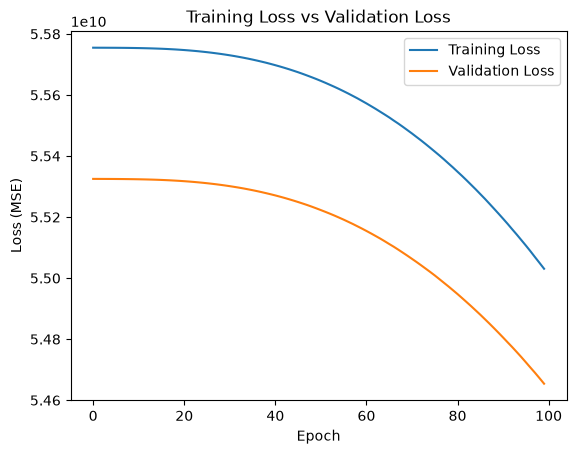

In [78]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
plt.plot(history_df.index, history_df['loss'], label='Training Loss')
plt.plot(history_df.index, history_df['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss vs Validation Loss')
plt.legend()

plt.show()

## 12. Early Stopping (callback)

- Prevent overfitting
- will not waste the computing power
- save time
  
It is hard to guess exactly how many epochs a model needs. If you train for too few epochs, the model underfits. If you train for too many, it overfits. 

An **Early Stopping Callback** acts as an automatic brake. It monitors the validation loss and automatically stops training once the validation score stops improving, even if you haven't reached your maximum number of epochs. It can also automatically restore the model's best weights!

In [79]:
# configure EarlyStopping parameters
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [80]:
# Use the validation
# Step 1: Define
early_model = Sequential()

early_model.add(Input(shape=(3,)))
early_model.add(Dense(16, activation='relu'))
early_model.add(Dense(8, activation='relu'))
early_model.add(Dense(1, activation='linear'))


# Step 2: Compile
early_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Step 3: Fit
history_early = early_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 55754956800.0000 - mae: 219578.1406 - val_loss: 55325110272.0000 - val_mae: 220286.5156
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 55754891264.0000 - mae: 219578.0000 - val_loss: 55325057024.0000 - val_mae: 220286.3906
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754829824.0000 - mae: 219577.8906 - val_loss: 55324999680.0000 - val_mae: 220286.2812
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 55754747904.0000 - mae: 219577.7188 - val_loss: 55324925952.0000 - val_mae: 220286.1250
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754657792.0000 - mae: 219577.5469 - val_loss: 55324827648.0000 - val_mae: 220285.9219
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754547200.0000 - mae: 219577.2969 - val_loss: 55324721152.0000 - val_mae: 220285.6875
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55754407936.0000 - mae: 219577.0312 - val_loss: 553245859

In [85]:
# Model Weights
early_model.weights

[<Variable path=sequential_22/dense_65/kernel, shape=(3, 16), dtype=float32, value=[[  8.687677    -9.193748     0.06217065   9.745037     9.48387
     9.581848     9.582124    -9.809372   -10.060632    -9.552673
     9.572771    -9.606403    -9.711045     9.12225      8.920663
     9.230405  ]
  [  9.331178    -9.079436     0.05284608   9.94643      9.173519
     9.648456     9.467771    -8.851757    -8.907538    -9.408025
     9.4802685   -9.3221245   -9.470213     9.648744     9.890297
     8.960347  ]
  [  9.03048     -9.721429    -0.12045626   8.605984     8.618613
     9.158442     9.215845   -10.32988    -10.022815   -10.334236
     8.689324    -9.61406    -10.139974     9.511268     9.370366
     9.437578  ]]>,
 <Variable path=sequential_22/dense_65/bias, shape=(16,), dtype=float32, value=[10.345516   10.135582   -0.16554694 10.535835   10.377099   10.535783
  10.610949   10.5469885  10.475785   10.610198   10.446513   10.55859
  10.309445   10.522003   10.483508   10.492016  ]

In [86]:
# Model Summary
early_model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

In [87]:
# Create a History Data Frame
history_df = pd.DataFrame(history_early.history)

history_df.head()

,loss,mae,val_loss,val_mae
0,5.575496e+10,219578.140625,5.532511e+10,220286.515625
1,5.575489e+10,219578.000000,5.532506e+10,220286.390625
2,5.575483e+10,219577.890625,5.532500e+10,220286.281250
3,5.575475e+10,219577.718750,5.532493e+10,220286.125000
4,5.575466e+10,219577.546875,5.532483e+10,220285.921875


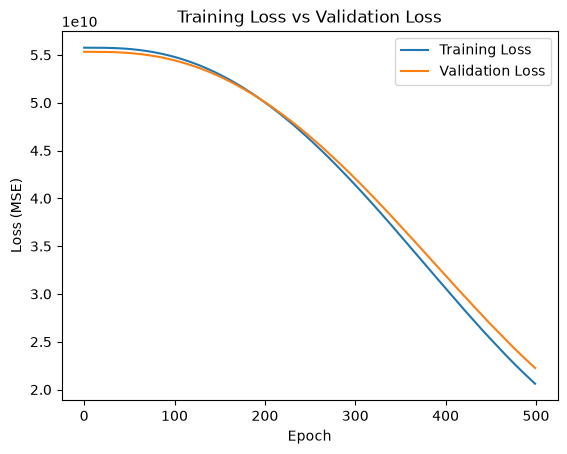

In [88]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss

plt.plot(history_df.index, history_df['loss'], label='Training Loss')
plt.plot(history_df.index, history_df['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss vs Validation Loss')
plt.legend()

plt.show()

## 13.Multi-Feature Neural Network

In [ ]:
# configure EarlyStopping parameters
# Already Done

In [ ]:
# Use the validation
# Step 1: Define



# Step 2: Compile 



# Step 3: Fit



In [ ]:
# Model Weights


In [ ]:
# Model Summary


In [ ]:
# Create a History Data Frame


In [ ]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
